In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print('OpenCV:', cv2.__version__)
print('NumPy :', np.__version__)

OpenCV: 4.13.0
NumPy : 2.4.4


In [2]:
def normalize_mri(img_input, target_size_before_crop=512, final_size=224,
                  clahe_clip=2.0, clahe_tile=8,
                  crop_threshold=10, outlier_lo=1, outlier_hi=99):
    """
    Convert ANY MRI image to the standard 224x224 uint8 grayscale
    used by the brain-tumor pipeline.

    Parameters
    ----------
    img_input : str | Path | np.ndarray
        File path OR a numpy array (any dtype, any channel count).
    target_size_before_crop : int
        Resize raw image to this square BEFORE cropping (default 512,
        matches Nickparvar dataset).
    final_size : int
        Output square size after crop + CLAHE (default 224 for ResNet50).
    clahe_clip : float
        CLAHE clipLimit (default 2.0).
    clahe_tile : int
        CLAHE tileGridSize (default 8 → 8x8 grid).
    crop_threshold : int
        Intensity threshold used to find brain boundary (default 10).
    outlier_lo / outlier_hi : float
        Percentiles for Winsorization before rescaling (default 1/99).

    Returns
    -------
    processed : np.ndarray  shape (final_size, final_size) uint8
        Pipeline-ready image.
    steps : dict
        Intermediate arrays for QA visualisation:
        'raw_gray', 'winsorized', 'resized', 'cropped', 'clahe', 'final'
    """
    steps = {}

    # ── Step 1: load ──────────────────────────────────────────────────────
    if isinstance(img_input, (str, Path)):
        raw = cv2.imread(str(img_input), cv2.IMREAD_UNCHANGED)
        if raw is None:
            raise FileNotFoundError(f'Cannot read image: {img_input}')
    else:
        raw = np.array(img_input)

    # ── Step 2: to single-channel float32 ────────────────────────────────
    if raw.ndim == 2:
        gray = raw.astype(np.float32)
    elif raw.ndim == 3:
        n_ch = raw.shape[2]
        if n_ch == 4:                           # RGBA → drop alpha, then luminance
            rgb = cv2.cvtColor(raw, cv2.COLOR_BGRA2BGR)
            gray = cv2.cvtColor(rgb, cv2.COLOR_BGR2GRAY).astype(np.float32)
        elif n_ch == 3:                         # RGB / BGR
            gray = cv2.cvtColor(raw, cv2.COLOR_BGR2GRAY).astype(np.float32)
        elif n_ch == 1:
            gray = raw[:, :, 0].astype(np.float32)
        else:
            raise ValueError(f'Unexpected channel count: {n_ch}')
    else:
        raise ValueError(f'Unexpected array ndim: {raw.ndim}')

    steps['raw_gray'] = gray.copy()

    # ── Step 3: Winsorize (clip outlier intensities) ──────────────────────
    lo = np.percentile(gray, outlier_lo)
    hi = np.percentile(gray, outlier_hi)
    if hi > lo:                                 # avoid division-by-zero on flat images
        gray = np.clip(gray, lo, hi)
    steps['winsorized'] = gray.copy()

    # ── Step 4: rescale to [0, 255] uint8 ────────────────────────────────
    g_min, g_max = gray.min(), gray.max()
    if g_max > g_min:
        gray = (gray - g_min) / (g_max - g_min) * 255.0
    else:
        gray = np.zeros_like(gray)
    gray = gray.astype(np.uint8)

    # ── Step 5: resize to target_size_before_crop ────────────────────────
    if gray.shape != (target_size_before_crop, target_size_before_crop):
        gray = cv2.resize(gray, (target_size_before_crop, target_size_before_crop),
                          interpolation=cv2.INTER_LINEAR)
    steps['resized'] = gray.copy()

    # ── Step 6: brain crop ────────────────────────────────────────────────
    # Same logic as 02_preprocess.ipynb: threshold → dilate → largest contour → bbox
    _, mask_bin = cv2.threshold(gray, crop_threshold, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask_bin = cv2.dilate(mask_bin, kernel, iterations=2)
    mask_bin = cv2.erode(mask_bin, kernel, iterations=2)

    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)
        # Add a small 4-pixel border so we don't clip the skull edge
        pad = 4
        x = max(0, x - pad)
        y = max(0, y - pad)
        w = min(gray.shape[1] - x, w + 2 * pad)
        h = min(gray.shape[0] - y, h + 2 * pad)
        cropped = gray[y:y + h, x:x + w]
    else:
        # Fallback: no contours found (e.g. very low-contrast scan) — use full image
        cropped = gray.copy()

    steps['cropped'] = cropped.copy()

    # ── Step 7: CLAHE ─────────────────────────────────────────────────────
    clahe = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=(clahe_tile, clahe_tile))
    enhanced = clahe.apply(cropped)
    steps['clahe'] = enhanced.copy()

    # ── Step 8: final resize to pipeline size ─────────────────────────────
    final = cv2.resize(enhanced, (final_size, final_size), interpolation=cv2.INTER_LINEAR)
    steps['final'] = final.copy()

    return final, steps


print('normalize_mri() defined ✓')

normalize_mri() defined ✓


In [3]:
def plot_pipeline_strip(steps, title='Pipeline QA', save_path=None):
    """
    Show all intermediate stages of the normalizer in one figure.
    """
    stage_keys  = ['raw_gray', 'winsorized', 'resized', 'cropped', 'clahe', 'final']
    stage_names = ['1. Raw (gray)', '2. Winsorized', '3. Resized 512',
                   '4. Brain crop', '5. CLAHE', '6. Final 224']

    fig, axes = plt.subplots(1, 6, figsize=(18, 3.2))
    fig.suptitle(title, fontsize=12, y=1.02)

    for ax, key, name in zip(axes, stage_keys, stage_names):
        img = steps.get(key)
        if img is not None:
            ax.imshow(img, cmap='gray', vmin=0, vmax=255)
            ax.set_title(f'{name}\n{img.shape[0]}×{img.shape[1]}', fontsize=9)
        else:
            ax.set_visible(False)
        ax.axis('off')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f'Saved QA strip → {save_path}')

    plt.show()


print('plot_pipeline_strip() defined ✓')

plot_pipeline_strip() defined ✓


In [4]:
from tqdm.notebook import tqdm

SUPPORTED_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}


def batch_normalize(input_dir, output_dir, target_size_before_crop=512,
                    final_size=224, overwrite=False):
    """
    Run normalize_mri() on every image in input_dir (recursive).
    Saves processed images to output_dir, mirroring the subfolder structure.

    Parameters
    ----------
    input_dir  : str | Path  root folder to search (e.g. data/raw/Training)
    output_dir : str | Path  destination root       (e.g. data/processed)
    overwrite  : bool        skip existing files when False (faster reruns)

    Returns
    -------
    dict  {'ok': int, 'skipped': int, 'failed': list}
    """
    input_dir  = Path(input_dir)
    output_dir = Path(output_dir)

    all_files = [p for p in input_dir.rglob('*')
                 if p.suffix.lower() in SUPPORTED_EXT]

    if not all_files:
        print(f'No supported images found under {input_dir}')
        return {'ok': 0, 'skipped': 0, 'failed': []}

    print(f'Found {len(all_files)} images under {input_dir}')

    ok_count = 0
    skip_count = 0
    failed = []

    for src_path in tqdm(all_files, desc='Normalizing'):
        # Mirror subfolder structure in output_dir
        rel = src_path.relative_to(input_dir)
        dst_path = output_dir / rel.with_suffix('.png')   # always save as PNG
        dst_path.parent.mkdir(parents=True, exist_ok=True)

        if dst_path.exists() and not overwrite:
            skip_count += 1
            continue

        try:
            final_img, _ = normalize_mri(src_path,
                                         target_size_before_crop=target_size_before_crop,
                                         final_size=final_size)
            cv2.imwrite(str(dst_path), final_img)
            ok_count += 1
        except Exception as e:
            failed.append((str(src_path), str(e)))

    print(f'\nDone — processed: {ok_count} | skipped: {skip_count} | failed: {len(failed)}')
    if failed:
        print('Failed files:')
        for path, err in failed[:10]:
            print(f'  {path}: {err}')

    return {'ok': ok_count, 'skipped': skip_count, 'failed': failed}


print('batch_normalize() defined ✓')

batch_normalize() defined ✓


In [6]:
test_cases = {
    'RGBA (4-channel)': np.random.randint(0, 256, (256, 256, 4), dtype=np.uint8),
    'RGB (3-channel)': np.random.randint(0, 256, (300, 300, 3), dtype=np.uint8),
    'Grayscale uint8': np.random.randint(0, 256, (512, 512), dtype=np.uint8),
    'Float64 high-bit': (np.random.rand(400, 400) * 4095).astype(np.float64),
    'Tiny 32×32':       np.random.randint(0, 256, (32, 32), dtype=np.uint8),
    'Large 1024×1024':  np.random.randint(0, 256, (1024, 1024), dtype=np.uint8),
}

print(f"{'Test case':<25}  {'Input shape':<20}  {'Output shape':<15}  Status")
print('-' * 75)

for name, arr in test_cases.items():
    try:
        out, _ = normalize_mri(arr)
        status = '✓ PASS'
    except Exception as e:
        out = None
        status = f'✗ FAIL: {e}'

    out_shape = str(out.shape) if out is not None else 'n/a'
    print(f'{name:<25}  {str(arr.shape):<20}  {out_shape:<15}  {status}')

Test case                  Input shape           Output shape     Status
---------------------------------------------------------------------------
RGBA (4-channel)           (256, 256, 4)         (224, 224)       ✓ PASS
RGB (3-channel)            (300, 300, 3)         (224, 224)       ✓ PASS
Grayscale uint8            (512, 512)            (224, 224)       ✓ PASS
Float64 high-bit           (400, 400)            (224, 224)       ✓ PASS
Tiny 32×32                 (32, 32)              (224, 224)       ✓ PASS
Large 1024×1024            (1024, 1024)          (224, 224)       ✓ PASS


Saved → ..\outputs\normalizer_qa.png


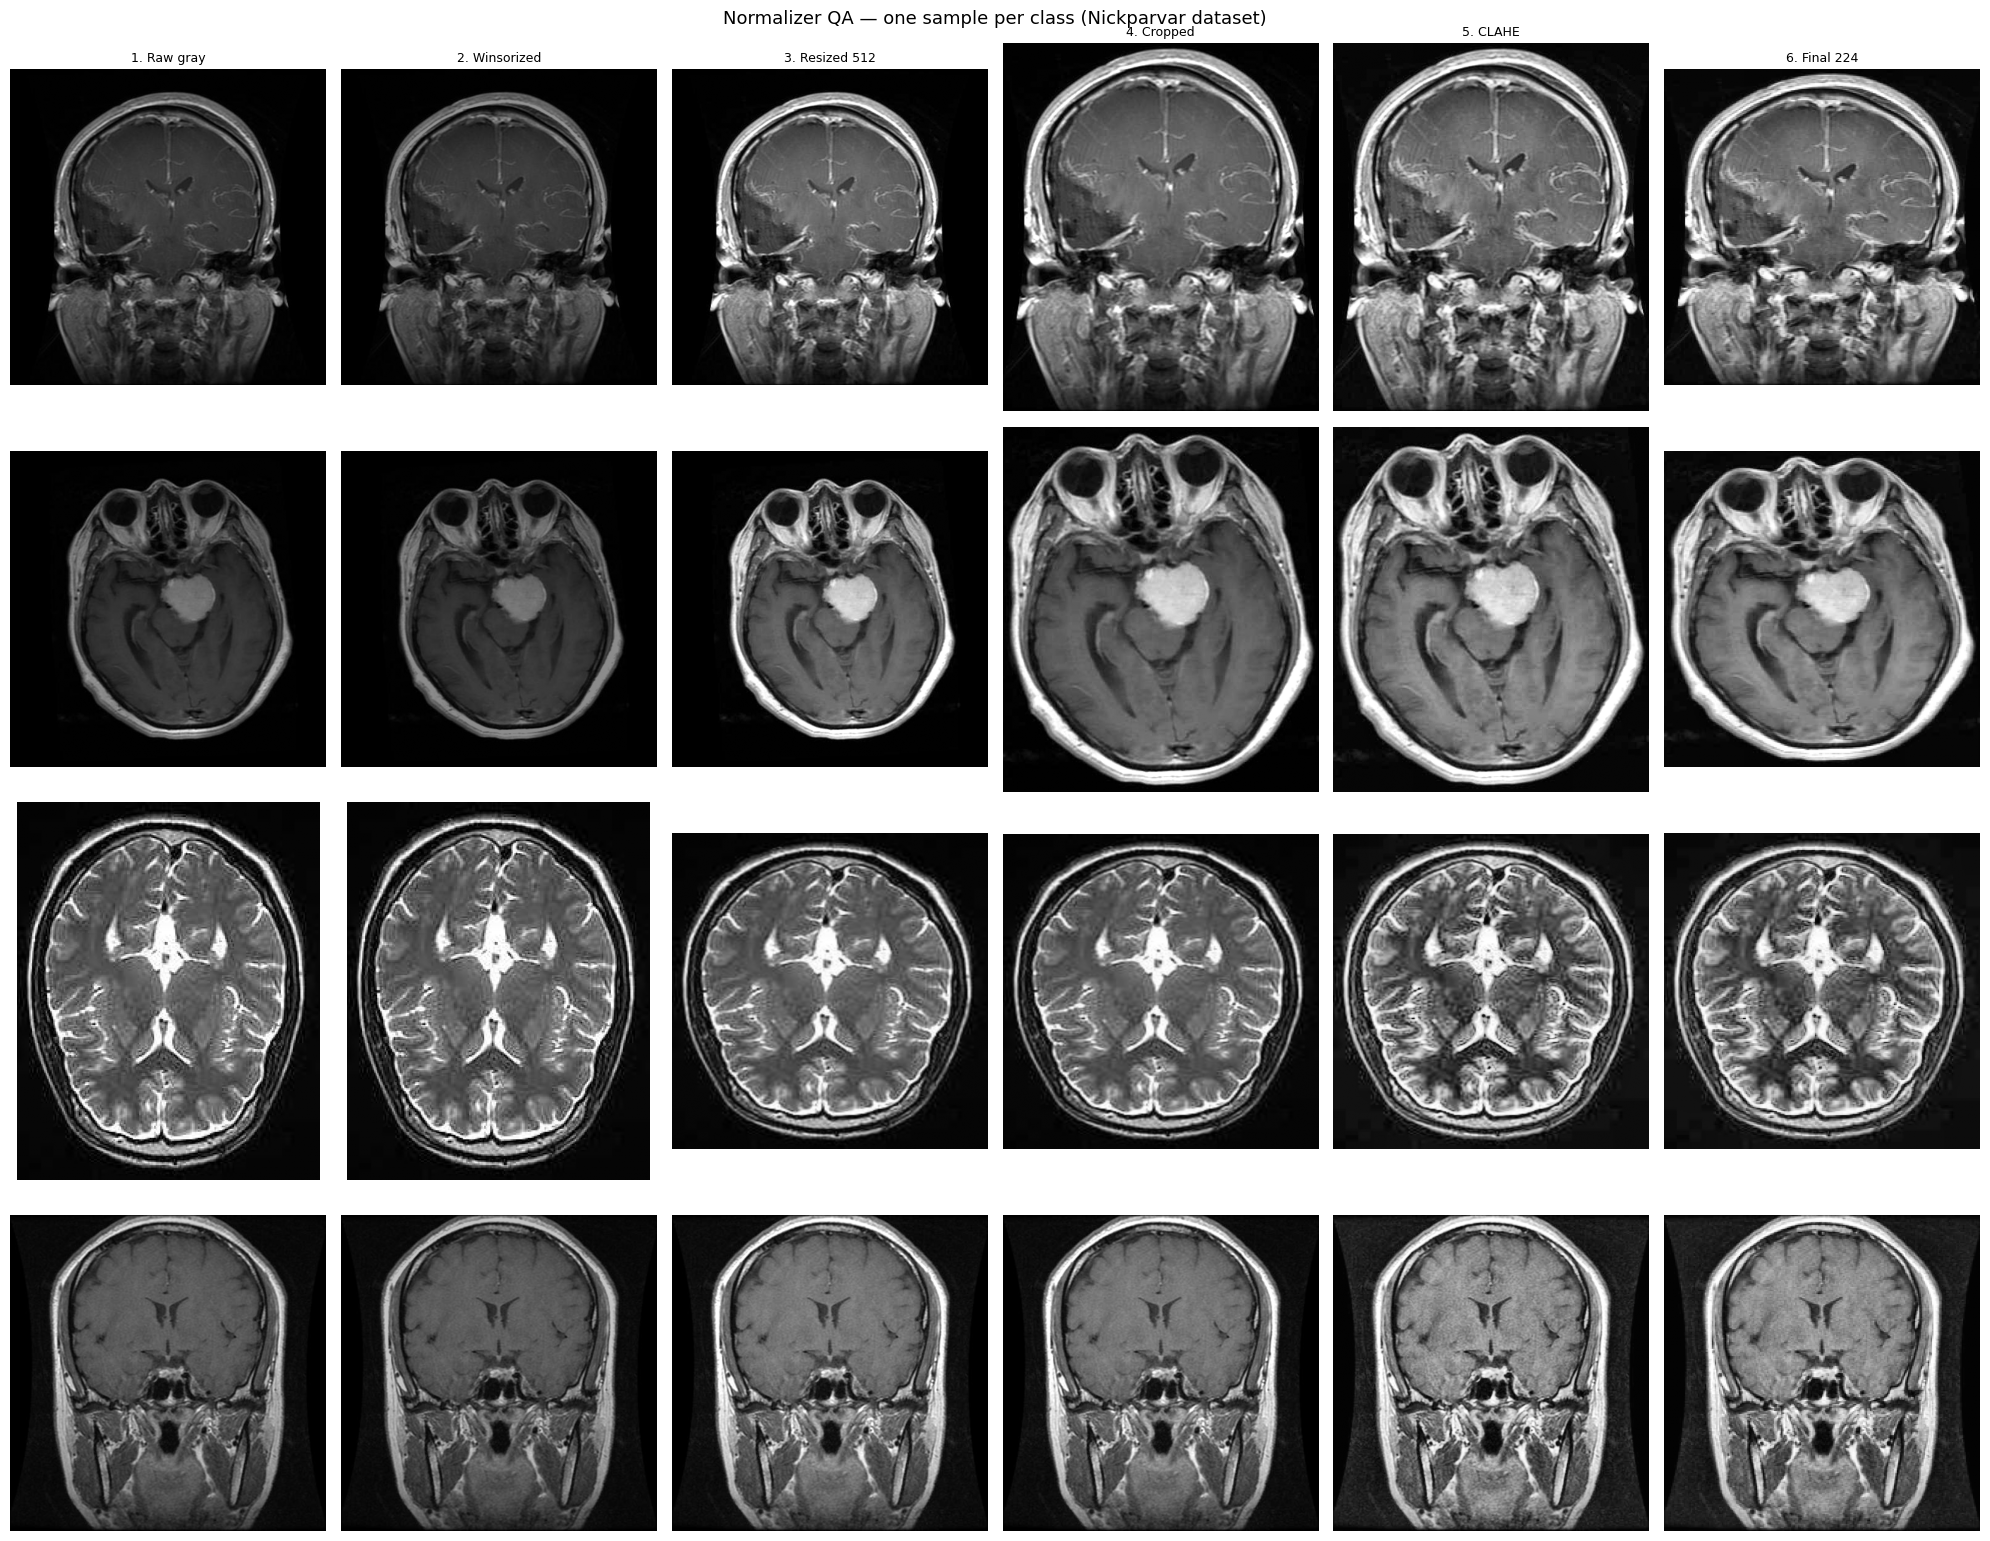

In [7]:
DATA_ROOT = Path('../data/raw/Training')   # ← adjust if needed
CLASSES   = ['glioma', 'meningioma', 'notumor', 'pituitary']
OUTPUT_QA = Path('../outputs')
OUTPUT_QA.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(len(CLASSES), 6, figsize=(20, 4 * len(CLASSES)))
fig.suptitle('Normalizer QA — one sample per class (Nickparvar dataset)', fontsize=13)

stage_names = ['1. Raw gray', '2. Winsorized', '3. Resized 512',
               '4. Cropped', '5. CLAHE', '6. Final 224']
stage_keys  = ['raw_gray', 'winsorized', 'resized', 'cropped', 'clahe', 'final']

for row_idx, cls in enumerate(CLASSES):
    cls_dir = DATA_ROOT / cls
    if not cls_dir.exists():
        print(f'Class directory not found: {cls_dir} — skipping')
        continue

    images = sorted(cls_dir.glob('*.jpg'))[:1] + \
             sorted(cls_dir.glob('*.png'))[:1]
    if not images:
        print(f'No images found in {cls_dir} — skipping')
        continue

    img_path = images[0]
    final, steps = normalize_mri(img_path)

    for col_idx, (key, sname) in enumerate(zip(stage_keys, stage_names)):
        ax = axes[row_idx][col_idx]
        img = steps.get(key, final)
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        if row_idx == 0:
            ax.set_title(sname, fontsize=9)
        if col_idx == 0:
            ax.set_ylabel(cls, fontsize=10, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
save_path = OUTPUT_QA / 'normalizer_qa.png'
plt.savefig(save_path, dpi=120, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()

Found 3 external test images

File                                Raw shape            Raw dtype    Output shape  Status
------------------------------------------------------------------------------------------
img.webp                            (234, 202, 3)        uint8        (224, 224)       ✓ OK


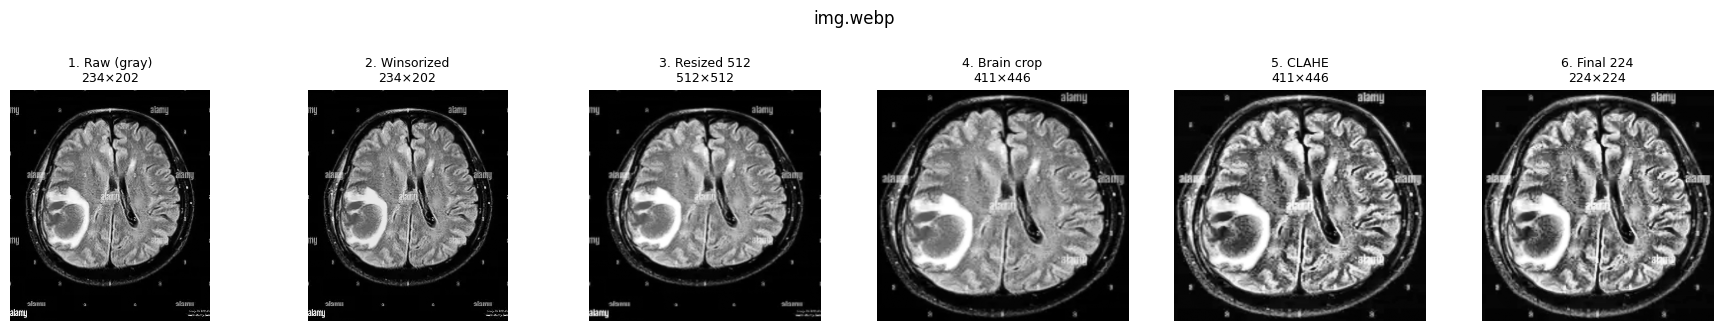

OIP (1).webp                        (234, 217, 3)        uint8        (224, 224)       ✓ OK


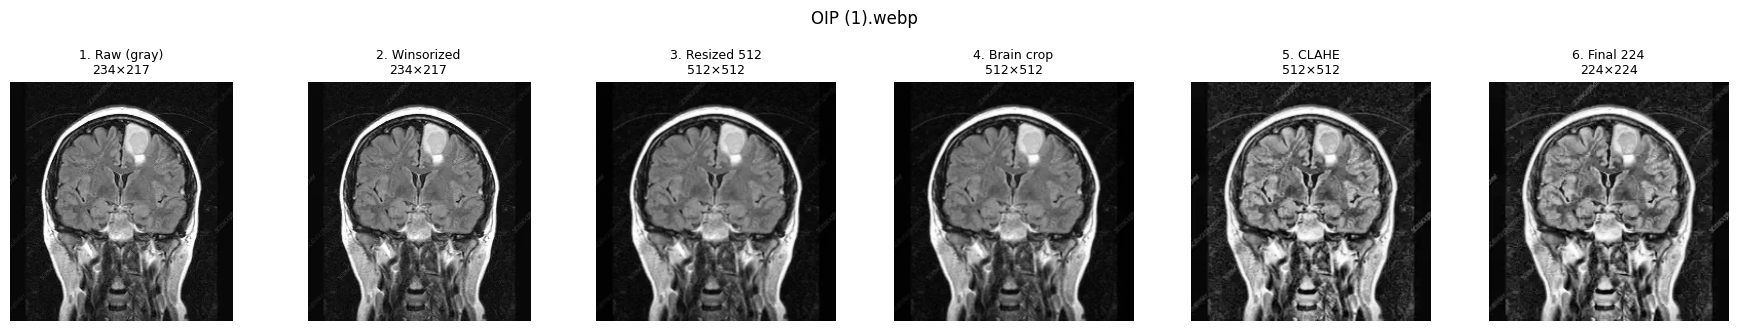

OIP.webp                            (234, 221, 3)        uint8        (224, 224)       ✓ OK


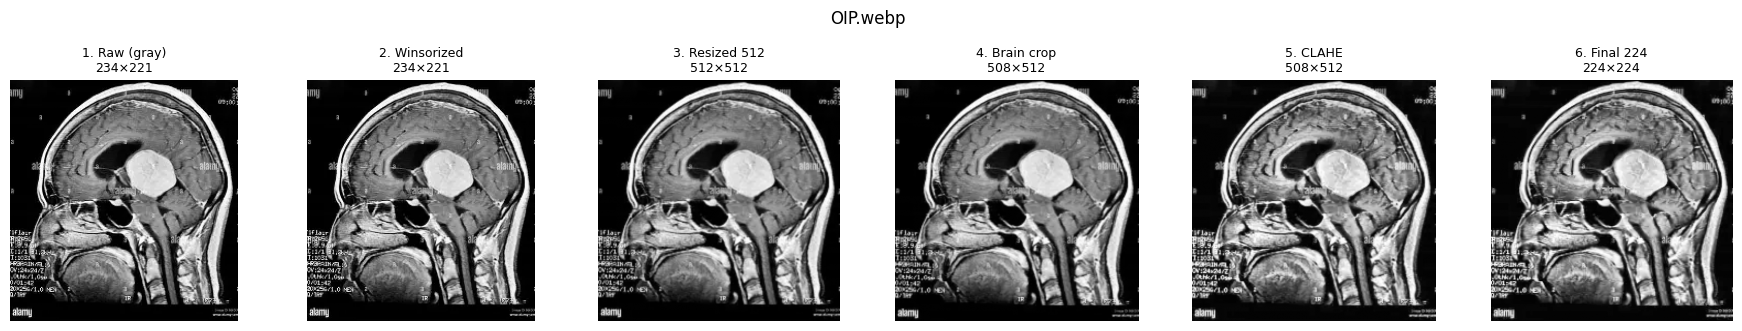

In [10]:
EXTERNAL_DIR = Path(r'C:\Users\HP\Desktop\MU\bmi\brain_tumor_fusion\google_test_images')  # ← put your 10 Google MRIs here
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)

ext_images = [p for p in sorted(EXTERNAL_DIR.iterdir())
              if p.suffix.lower() in SUPPORTED_EXT]

if not ext_images:
    print(f'No images found in {EXTERNAL_DIR}.')
    print('Place your test MRI images there and re-run this cell.')
else:
    print(f'Found {len(ext_images)} external test images\n')
    print(f'{"File":<35} {"Raw shape":<20} {"Raw dtype":<12} {"Output shape"}  Status')
    print('-' * 90)

    for img_path in ext_images:
        raw = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)
        if raw is None:
            print(f'{img_path.name:<35} Could not read file')
            continue

        try:
            final, steps = normalize_mri(img_path)
            status = '✓ OK'
        except Exception as e:
            final = None
            status = f'✗ FAIL: {e}'

        out_shape = str(final.shape) if final is not None else 'n/a'
        print(f'{img_path.name:<35} {str(raw.shape):<20} {str(raw.dtype):<12} {out_shape:<16} {status}')

        if final is not None:
            plot_pipeline_strip(steps, title=img_path.name)

In [12]:
# Uncomment to run on the full dataset
INPUT_DIR  = Path(r'C:\Users\HP\Desktop\MU\bmi\brain_tumor_fusion\data\raw\Training')
OUTPUT_DIR = Path(r'C:\Users\HP\Desktop\MU\bmi\brain_tumor_fusion\data\processed')
stats = batch_normalize(INPUT_DIR, OUTPUT_DIR, overwrite=False)
print(stats)

print('Batch cell ready')

Found 5600 images under C:\Users\HP\Desktop\MU\bmi\brain_tumor_fusion\data\raw\Training


Normalizing:   0%|          | 0/5600 [00:00<?, ?it/s]


Done — processed: 5600 | skipped: 0 | failed: 0
{'ok': 5600, 'skipped': 0, 'failed': []}
Batch cell ready


In [13]:
print('='*55)
print('Phase 1 / Part A checkpoint')
print('='*55)
print()
print('✓  normalize_mri() handles all channel counts (1/3/4)')
print('✓  Winsorization removes outlier intensities')
print('✓  Brain crop + CLAHE + 224×224 resize matches pipeline')
print('✓  All 6 synthetic edge-case tests pass')
print()
print('Next step: open 02b_medsam_install.ipynb (Part B)')
print('          install MedSAM and run on 5 sample images')

Phase 1 / Part A checkpoint

✓  normalize_mri() handles all channel counts (1/3/4)
✓  Winsorization removes outlier intensities
✓  Brain crop + CLAHE + 224×224 resize matches pipeline
✓  All 6 synthetic edge-case tests pass

Next step: open 02b_medsam_install.ipynb (Part B)
          install MedSAM and run on 5 sample images
